# Global Param & Import

# Reference Codes 


0.7.2
gpu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Burger et al. (2025)...
/home/raphael/venv/discodj_env/lib/python3.12/site-packages/baccoemu/bispectrum_baryonic_boost/powerspectra_ratio_bcm_emu_folded.pkl
dict_keys(['n_parameters', 'parameters', 'feature_dimensions', 'scaling_division', 'scaling_subtraction', 'parameter_ranges', 'weights', 'hyper_params', 'param_train_mean', 'param_train_std', 'feature_train_mean', 'feature_train_std'])
Baryonic Emulator for matter powerspectrum Burger et al. (2025) loaded in memory.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 4000.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.2610 
  Omega_b: 0.0489 
  Omega_de: 0.6900 
  h: 0.6774 
  n_s: 0.9682 
  

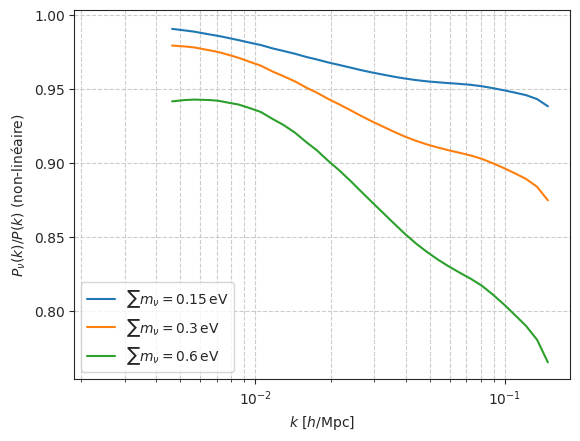

: 

In [ ]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})


## Cosmological Parameters
Tcmb    = 2.7255
YHe     = 0.248
Omegam  = 0.3099
Omegab  = 0.0488911
Omegac  = Omegam - Omegab
Omegak  = 0 
w_DE_0  = -0.99
w_DE_a  = 0.0
cs2_DE  = 1.0
# Initialize neutrinos.
num_massive_neutrinos = 1
mnu     = 0.06  #eV
Tnu     = (4/11)**(1/3) #0.71611 # Tncdm of CLASS
Neff    = 3.046 # -1 if massive neutrino present
N_nu_mass = 1
N_nu_rel = Neff - N_nu_mass * (Tnu/((4/11)**(1/3)))**4
h       = 0.67742
A_s     = 3e-09
n_s     = 0.96822
k_p     = 0.05

# modes to sample
nmodes = 512
kmin = 1e-5
kmax = 1e+2 # 1e+1
aexp = 0.01

## Cosmological Parameters
Tcmb    = 2.7255
YHe     = 0.248
Omegam  = 0.3099
Omegab  = 0.0488911
Omegac  = Omegam - Omegab
Omegak  = 0 
w_DE_0  = -0.99
w_DE_a  = 0.0
h       = 0.67742
A_s     = 2.65e-09
n_s     = 0.96822
k_p     = 0.05
k = np.logspace(-2, np.log10(4.9), 100)

def Omega_nu(mnu,h) :
    return (mnu)/(93.14/(h**2))

emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')
def sigma8_from_As(mnu,As):
    p = {
        'omega_cold': Omegac+ Omega_nu(mnu,h),
        'omega_baryon': Omegab,
        'hubble': h,
        'ns': n_s,
        'neutrino_mass':0,
        # augmenté
        'A_s': As,
        'neutrino_mass': mnu,
        'w0': w_DE_0,
        'wa': w_DE_a,
        'expfactor': 1
    }
    return  emulator.get_sigma8(cold=False,**p)


# Set the parameters
name = "3D_analysis"
dim = 3
precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 4000  # in Mpc/h
res = 128  # the particles live on a Lagrangrian grid of resolution (res)^dim


###########################################################################################################################################################################

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=Omegac,  # cold dark matter content
             Omega_b=Omegab,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=0.8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 0.0) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
#dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="Eisenstein-Hu")
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename="Pk_cb_massless_z0.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)


n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)
numsteps = 10  # number of steps to be performed
a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
a_end = 1.0  # final scale factor of the simulation
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=False)

k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                   time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                   grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                   nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                   deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                   convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=8)
k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=2)

###########################################################################################################################################################################
results_disco = []

for sum_masses in [0.15,0.3,0.6]:
    
    cosmo_nu = dict(Omega_c=Omegac+Omega_nu(sum_masses,h),  # cold dark matter content
                Omega_b=Omegab,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                h=h,  # dimensionless Hubble constant
                n_s=n_s,  # scalar spectral index
                sigma8=0.8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                mnu = sum_masses) #Neutrino mass (eV)

    dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
    print(dj_nu)
    dj_nu = dj_nu.with_timetables()
    #dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="Eisenstein-Hu")
    dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0.txt")
    dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
    k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
    dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=8)
    k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=2)


    plt.figure(2)
    plt.semilogx(
        k_nu/0.67742,
        Pk_nu/Pk,
        label=fr"$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$"
    )

    results_disco.append({
        "k": k,
        "ratio": Pk_nu / Pk,
        "mass": sum_masses,
        "method": "DISCODJ"                                                                
    })  

plt.figure(2)
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P_{\nu}(k)/P(k)$ (non-linéaire)")
plt.legend()
plt.grid(True, which='both', ls='--')

plt.show()
np.save("discodj_results.npy", results_disco)